# 04 — Model Architectures (GRU & Transformer, multi-task heads)

Prototypes and sanity-checks the two encoders used across the four planned
experiments (see [docs/ml-design-report.md §3](../docs/ml-design-report.md#3-model-architectures-planned-not-yet-implemented)):
a GRU and a Transformer, each with a classification head (`y`) and an
optional auxiliary HRF-regression head (`y_hrf`).


In [1]:
from __future__ import annotations

import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "environment.yml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the NeuroLens repository root.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurolens.data_setup import make_dataloaders

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "hcp_ya_s1200" / "runs"
train_loader, val_loader, test_loader, info = make_dataloaders(PROCESSED_ROOT, batch_size=64)
batch = next(iter(train_loader))
x = batch["x"]
print("batch x:", x.shape, "num_classes:", info["num_classes"], "num_conditions:", info["num_conditions"])


batch x: torch.Size([64, 32, 300]) num_classes: 6 num_conditions: 5


## 1. Prototype: GRU encoder

`X [B, 32, 300] -> GRU -> final hidden state [B, hidden_size] -> classifier / HRF regressor`.

In [2]:
class ProtoGRUDecoder(nn.Module):
    def __init__(self, input_size=300, hidden_size=128, num_layers=1, num_classes=6, num_conditions=5, include_hrf_head=True):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.classifier = nn.Linear(hidden_size, num_classes)
        self.hrf_head = nn.Linear(hidden_size, num_conditions) if include_hrf_head else None

    def forward(self, x):
        _, h_n = self.gru(x)          # h_n: [num_layers, B, hidden_size]
        h = h_n[-1]                    # final layer's hidden state: [B, hidden_size]
        logits = self.classifier(h)
        hrf_pred = self.hrf_head(h) if self.hrf_head is not None else None
        return logits, hrf_pred


proto_gru = ProtoGRUDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"])
logits, hrf_pred = proto_gru(x)
print("GRU logits:", logits.shape, "hrf_pred:", hrf_pred.shape)
assert logits.shape == (x.shape[0], info["num_classes"])
assert hrf_pred.shape == (x.shape[0], info["num_conditions"])


GRU logits: torch.Size([64, 6]) hrf_pred: torch.Size([64, 5])


## 2. Prototype: Transformer encoder

`X [B, 32, 300] -> Linear(300->128) -> + sinusoidal positional encoding -> TransformerEncoder -> final token -> heads`.

One fMRI volume = one token; no NLP-style vocabulary or subword tokenizer is used (see [docs/ml-design-report.md §2](../docs/ml-design-report.md#2-input--output-specification)).

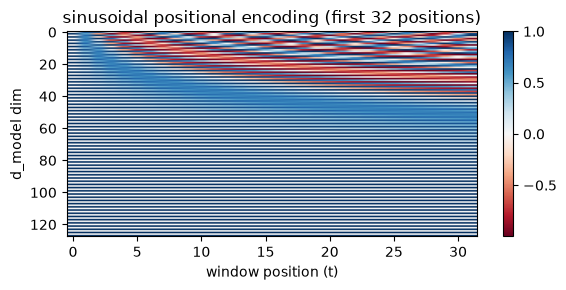

In [3]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[: pe[:, 1::2].shape[1]])
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]


pos_enc = SinusoidalPositionalEncoding(d_model=128, max_len=64)
plt.figure(figsize=(6, 3))
plt.imshow(pos_enc.pe[0, :32].numpy().T, aspect="auto", cmap="RdBu")
plt.xlabel("window position (t)")
plt.ylabel("d_model dim")
plt.title("sinusoidal positional encoding (first 32 positions)")
plt.colorbar()
plt.tight_layout()
plt.show()


In [4]:
class ProtoTransformerDecoder(nn.Module):
    def __init__(self, input_size=300, d_model=128, n_heads=4, n_layers=2, dim_feedforward=256,
                 dropout=0.1, num_classes=6, num_conditions=5, include_hrf_head=True, max_len=512):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoding = SinusoidalPositionalEncoding(d_model, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.classifier = nn.Linear(d_model, num_classes)
        self.hrf_head = nn.Linear(d_model, num_conditions) if include_hrf_head else None

    def forward(self, x):
        h = self.input_proj(x)
        h = self.pos_encoding(h)
        h = self.encoder(h)         # [B, L, d_model]
        pooled = h[:, -1, :]        # final temporal token (causal v1 pooling choice)
        logits = self.classifier(pooled)
        hrf_pred = self.hrf_head(pooled) if self.hrf_head is not None else None
        return logits, hrf_pred


proto_transformer = ProtoTransformerDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"])
logits, hrf_pred = proto_transformer(x)
print("Transformer logits:", logits.shape, "hrf_pred:", hrf_pred.shape)
assert logits.shape == (x.shape[0], info["num_classes"])
assert hrf_pred.shape == (x.shape[0], info["num_conditions"])


Transformer logits: torch.Size([64, 6]) hrf_pred: torch.Size([64, 5])


## 3. Parameter counts across all four experiment architectures

In [5]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


variants = {
    "Exp1: GRU, cls-only": ProtoGRUDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=False),
    "Exp2: GRU, cls+HRF": ProtoGRUDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True),
    "Exp3: Transformer, cls-only": ProtoTransformerDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=False),
    "Exp4: Transformer, cls+HRF": ProtoTransformerDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True),
}
for name, model in variants.items():
    print(f"{name:32s} params={count_parameters(model):,}")


Exp1: GRU, cls-only              params=165,894
Exp2: GRU, cls+HRF               params=166,539
Exp3: Transformer, cls-only      params=304,262
Exp4: Transformer, cls+HRF       params=304,907


## 4. Refactor into `src/neurolens/model_builder.py`

Both architectures above are consolidated into `src/neurolens/model_builder.py`
(`GRUDecoder`, `TransformerDecoder`), each accepting `include_hrf_head` so
classification-only experiments use a model that architecturally has no
regression head, rather than one with an unused head.

In [6]:
from neurolens.model_builder import GRUDecoder, TransformerDecoder, count_parameters as module_count_parameters

module_gru = GRUDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True)
module_transformer = TransformerDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True)

for name, model in [("GRUDecoder", module_gru), ("TransformerDecoder", module_transformer)]:
    logits, hrf_pred = model(x)
    print(f"{name}: logits={tuple(logits.shape)} hrf_pred={tuple(hrf_pred.shape)} params={module_count_parameters(model):,}")

print("model_builder.py architectures verified against the prototypes above.")


GRUDecoder: logits=(64, 6) hrf_pred=(64, 5) params=166,539
TransformerDecoder: logits=(64, 6) hrf_pred=(64, 5) params=304,907
model_builder.py architectures verified against the prototypes above.


## Summary

- GRU: `input_size=300, hidden_size=128, num_layers=1` — ~166K params (multi-task) / ~166K (cls-only, negligible difference).
- Transformer: `d_model=128, n_heads=4, n_layers=2, feedforward=256, dropout=0.1`, final-token pooling — ~305K params.
- Both consolidated into `src/neurolens/model_builder.py`, reused by `05_train_eval_compare.ipynb`.
